In [1]:
# ============================================================================
# CELL 1: ENVIRONMENT CHECK (SAFE FOR VERSIONS)
# ============================================================================

import numpy as np, torch, torchvision

print("✅ Environment check")
print("  NumPy:", np.__version__)
print("  Torch:", torch.__version__)
print("  TorchVision:", torchvision.__version__)

print("\nℹ️ If something is missing or versions are wrong,")
print("   run a separate SETUP notebook ONE TIME to install deps.")


✅ Environment check
  NumPy: 2.0.2
  Torch: 2.8.0+cu126
  TorchVision: 0.23.0+cu126

ℹ️ If something is missing or versions are wrong,
   run a separate SETUP notebook ONE TIME to install deps.


In [2]:
# ============================================================================
# CELL 2: CONFIGURATION + STAGE 1 DETECTION (UNZIP + MANUAL PIPELINE)
# ============================================================================

from dataclasses import dataclass, field
from typing import List
from pathlib import Path
import os, json, time, zipfile

print("="*70)
print("📦 UNZIPPING STAGE 1 OUTPUT + CONFIGURING PIPELINE")
print("="*70)

# ---- Unzip Stage 1 ----
zip_path = Path("/kaggle/input/notebooks/mrkdagods/gp-stage1-deepocsort/_output_.zip")
extract_root = Path("/kaggle/working/stage1_unzipped")

if not zip_path.exists():
    raise FileNotFoundError(f"❌ Stage 1 zip not found at: {zip_path}")

if not extract_root.exists():
    print(f"⏳ Extracting {zip_path} → {extract_root} ...")
    extract_root.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_root)
    print("✅ Extraction complete!")
else:
    print(f"✅ Already extracted, skipping unzip.")

print(f" • crops exists   : {(extract_root / 'crops').exists()}")
print(f" • tracklets exists: {(extract_root / 'tracklets.json').exists()}")

# ---- Pipeline flags ----
PIPELINE_MODE   = True
TRACKLET_FORMAT = "track"
STAGE1_PATH     = extract_root

print(f"\n Stage 1 path: {STAGE1_PATH}")
print("="*70)

# ============================================================================
# CONFIGURATION CLASSES
# ============================================================================

@dataclass
class ReIDConfig:
    backbone_type: str = "vidtransreid"
    vidtrans_seq_len: int = 4
    vidtrans_num_classes: int = 1000
    vidtrans_camera_num: int = 8
    vidtrans_use_pretrained: bool = True
    input_size: tuple = (256, 128)
    use_lighting_augmentation: bool = True
    use_rotation_augmentation: bool = True
    use_blur_augmentation: bool = True
    use_random_erasing: bool = True
    n_augmentations: int = 2
    use_horizontal_flip_tta: bool = True
    use_multiscale_tta: bool = False
    use_pca_whitening: bool = True
    pca_dim: int = 256
    use_reranking: bool = False
    rerank_k1: int = 30
    rerank_k2: int = 10
    rerank_lambda: float = 0.4
    use_query_expansion: bool = True
    qe_k: int = 3
    use_camera_embeddings: bool = False
    use_hsv_fusion: bool = True
    hsv_bins: int = 32
    hsv_weight: float = 0.025
    use_grayscale_augmentation: bool = True

@dataclass
class PathsConfig:
    input_base: str = "/kaggle/input"
    dataset_dir: str = "/kaggle/working/dataset"
    crops_root: str = str(STAGE1_PATH / "crops")
    weights_path: str = "/kaggle/working/yolov8_best.pt"
    track_json_path: str = str(STAGE1_PATH / "tracklets.json")
    features_path: str = "/kaggle/working/reid_features_improved.npz"
    vidtrans_vit_path: str = "/kaggle/working/jx_vit_base_p16_224-80ecf9dd.pth"

@dataclass
class YOLOConfig:
    conf_threshold: float = 0.3
    img_size: int = 640
    allowed_classes: dict = field(default_factory=lambda: {
        0: 'person', 1: 'car', 2: 'truck', 3: 'bus'
    })

@dataclass
class DataDiscoveryConfig:
    preferred_tokens: list = field(default_factory=lambda: ["dataset", "aicity", "yolo", "train"])
    exclude_tokens: list = field(default_factory=lambda: ["weights", "model"])

# Instantiate configs
REID_CFG   = ReIDConfig()
PATHS      = PathsConfig()
YOLO_CFG   = YOLOConfig()
DISCOVERY  = DataDiscoveryConfig()

print("="*70)
print("🔥 CONFIGURATION SUMMARY")
print("="*70)
print(f"Mode     : {'PIPELINE' if PIPELINE_MODE else 'STANDALONE'}")
print(f"Crops    : {PATHS.crops_root}")
print(f"Tracklets: {PATHS.track_json_path}")
print("="*70)


📦 UNZIPPING STAGE 1 OUTPUT + CONFIGURING PIPELINE
⏳ Extracting /kaggle/input/notebooks/mrkdagods/gp-stage1-deepocsort/_output_.zip → /kaggle/working/stage1_unzipped ...
✅ Extraction complete!
 • crops exists   : True
 • tracklets exists: True

 Stage 1 path: /kaggle/working/stage1_unzipped
🔥 CONFIGURATION SUMMARY
Mode     : PIPELINE
Crops    : /kaggle/working/stage1_unzipped/crops
Tracklets: /kaggle/working/stage1_unzipped/tracklets.json


In [3]:
# ============================================================================
# ============ CELL 3: AUGMENTATION TRANSFORMS (IMPROVED) ============
# ============================================================================
# 🔥 CHANGED: Scale from 70%-150% to 90%-110%

import torchvision.transforms as T
from torchvision.transforms import functional as F
import random

print("="*70)
print("🎨 AUGMENTATION TRANSFORMS (IMPROVED)")
print("="*70)

# Base preprocessing transform (moved here for clarity)
normalize_transform = T.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

base_transform = T.Compose([
    T.Resize((256, 256), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    normalize_transform,
])

# Random erasing (applied to tensors, not PIL Images)
random_erasing_transform = T.RandomErasing(
    p=0.5, 
    scale=(0.02, 0.2), 
    ratio=(0.3, 3.3), 
    value='random'
)

print("✅ Augmentation configured:")
print("  • Lighting: ±30% brightness, ±20% contrast")
print("  • 🔥 Geometric: 90%-110% scale (IMPROVED from 70%-150%)")
print("  • Reason: Realistic for highway cameras at 15-25m height")
print("  • Quality: Gaussian blur")
print("  • Random erasing: 50% prob, 2%-20% area")
print("="*70)


🎨 AUGMENTATION TRANSFORMS (IMPROVED)
✅ Augmentation configured:
  • Lighting: ±30% brightness, ±20% contrast
  • 🔥 Geometric: 90%-110% scale (IMPROVED from 70%-150%)
  • Reason: Realistic for highway cameras at 15-25m height
  • Quality: Gaussian blur
  • Random erasing: 50% prob, 2%-20% area


In [4]:
# ============================================================================
# ============ CELL 4: HELPER FUNCTIONS (IMPROVED - BOTH FORMATS) ============
# ============================================================================
# ✅ NEW: Handles both track-based and AI City formats

import cv2
import numpy as np
import re
from PIL import Image
from pathlib import Path
from typing import Optional

# ✅ NEW: Extract camera ID from filename (works for both formats)
def extract_camera_id(crop_path: Path) -> int:
    """
    Extract camera ID from crop filename.
    Example: 
      - AI City: "S02_c006_000042_cls1_0.jpg" → camera_id = 6
      - Track: "track_0001_frame_000042.jpg" → camera_id = 0 (unknown)
    """
    # Try AI City format first
    match = re.search(r'c(\d+)', str(crop_path))
    if match:
        return int(match.group(1))

    # Track format has no camera info
    return 0

# ✅ NEW: Extract scenario ID
def extract_scenario(crop_path: Path) -> str:
    """Extract scenario ID. Example: "S02_c006_..." → "S02" """
    match = re.search(r'(S\d+)', str(crop_path))
    return match.group(1) if match else "unknown"

# ✅ NEW: HSV color histogram
def extract_hsv_histogram(img: Image.Image, bins: int = 32) -> np.ndarray:
    """
    Extract HSV color histogram for vehicle color discrimination.

    Returns 96-dim histogram (32 bins × 3 channels).
    Helps distinguish vehicles by color (red car vs blue car).
    """
    img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2HSV)

    h_hist = cv2.calcHist([img_cv], [0], None, [bins], [0, 180]).flatten()
    s_hist = cv2.calcHist([img_cv], [1], None, [bins], [0, 256]).flatten()
    v_hist = cv2.calcHist([img_cv], [2], None, [bins], [0, 256]).flatten()

    hist = np.concatenate([h_hist, s_hist, v_hist])
    hist = hist / (hist.sum() + 1e-8)

    return hist.astype('float32')

# ✅ IMPROVED: Map tracklet frame to crop path (supports both formats)
def map_frame_to_crop(frame_path: str, crops_root: Path, split: str = 'val', 
                     format_type: str = 'aicity') -> Optional[Path]:
    """
    Map tracklet frame path to actual crop file.

    🔥 NEW: Supports both formats:
      - 'aicity': Maps "data/train/S02/c006/img1/000042.jpg" → "S02_c006_000042_cls1_0.jpg"
      - 'track': Uses path directly from JSON (e.g., "val/person/track_0001_frame_000042.jpg")

    Args:
        frame_path: Frame path from tracklets.json
        crops_root: Root directory of crops
        split: Dataset split ('val' or 'train')
        format_type: 'aicity' or 'track'

    Returns:
        Full path to crop file, or None if not found
    """

    if format_type == 'track':
        # 🔥 NEW: Track format - path is relative to crops_root
        # Example: "val/person/track_0001_frame_000042.jpg"
        crop_path = crops_root / frame_path
        return crop_path if crop_path.exists() else None

    else:
        # AI City format - need to parse and construct filename
        match = re.search(r'(S\d+)/(c\d+)/img\d+/(\d+)\.jpg', frame_path)
        if not match:
            return None

        scenario, camera, frame_num = match.groups()
        vid_key = f"{scenario}_{camera}"
        frame_int = int(frame_num)

        # Search for matching crop in all class directories
        crop_dir = crops_root / split
        for cls_name in ['person', 'car', 'truck', 'bus', 'vehicle']:
            cls_dir = crop_dir / cls_name
            if not cls_dir.exists():
                continue

            pattern = f"{vid_key}_{frame_int:06d}_cls*.jpg"
            matches = list(cls_dir.glob(pattern))

            if matches:
                return matches[0]

        return None

print("="*70)
print("✅ HELPER FUNCTIONS READY (BOTH FORMATS SUPPORTED)")
print("="*70)
print("   • extract_camera_id(): Get camera ID from filename")
print("   • extract_scenario(): Get scenario (S02, S05, etc.)")
print("   • extract_hsv_histogram(): 96-dim color histogram")
print("   • map_frame_to_crop(): Map tracklet frames to crops (both formats)")
print(f"   • Current format: {TRACKLET_FORMAT}")
print("="*70)

✅ HELPER FUNCTIONS READY (BOTH FORMATS SUPPORTED)
   • extract_camera_id(): Get camera ID from filename
   • extract_scenario(): Get scenario (S02, S05, etc.)
   • extract_hsv_histogram(): 96-dim color histogram
   • map_frame_to_crop(): Map tracklet frames to crops (both formats)
   • Current format: track


In [5]:
# ============================================================================
# CELL 5: FEATURE EXTRACTOR — FastReID SBS(R50-ibn) VeRi-776 Pretrained
# ============================================================================
# Rank@1: 97.0% | mAP: 81.9% on VeRi-776  (JDAI-CV/fast-reid v0.1.1)
# Drop-in replacement: same function signatures as VID-Trans-ReID cell

import subprocess, sys, os, random
import torch
import torch.nn.functional as F
import torchvision.transforms as T
import numpy as np
from PIL import Image
from pathlib import Path
from typing import List, Optional

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Device: {device}")

# ============================================================================
# STEP 1: Clone FastReID + Install minimal deps
# ============================================================================

FASTREID_ROOT = Path("/kaggle/working/fast-reid")

if not FASTREID_ROOT.exists():
    print("📦 Cloning FastReID (depth=1)...")
    subprocess.run([
        "git", "clone", "--depth", "1",
        "https://github.com/JDAI-CV/fast-reid.git",
        str(FASTREID_ROOT)
    ], check=True)
    print("✅ Cloned")

# Minimal deps FastReID needs beyond standard Kaggle env
subprocess.run(["pip", "install", "yacs", "termcolor", "tabulate", "-q"], check=True)

if str(FASTREID_ROOT) not in sys.path:
    sys.path.insert(0, str(FASTREID_ROOT))

from fastreid.config import get_cfg
from fastreid.modeling.meta_arch import build_model
from fastreid.utils.checkpoint import Checkpointer
print("✅ FastReID imported")

# ============================================================================
# STEP 2: Download VeRi-776 Pretrained Weights
# ============================================================================

weights_path = Path("/kaggle/working/veri_sbs_R50-ibn.pth")

if not weights_path.exists():
    print("⬇️ Downloading VeRi-776 SBS(R50-ibn) weights (~95MB)...")
    torch.hub.download_url_to_file(
        "https://github.com/JDAI-CV/fast-reid/releases/download/v0.1.1/veri_sbs_R50-ibn.pth",
        str(weights_path)
    )
    print(f"✅ Saved to {weights_path}")
else:
    print(f"✅ Weights already present: {weights_path}")

# ============================================================================
# STEP 3: Build Model
# ============================================================================

cfg = get_cfg()
cfg.merge_from_file(str(FASTREID_ROOT / "configs/VeRi/sbs_R50-ibn.yml"))
cfg.MODEL.BACKBONE.PRETRAIN = False   # Skip ImageNet backbone re-download
cfg.MODEL.WEIGHTS = ""                # We load manually below
cfg.freeze()

fastreid_model = build_model(cfg)
Checkpointer(fastreid_model).load(str(weights_path))
fastreid_model.eval().to(device)

# Read input size FastReID was trained with from its own config
FASTREID_SIZE = tuple(cfg.INPUT.SIZE_TEST)   # e.g. (256, 256) for VeRi
print(f"   Input size from config: {FASTREID_SIZE}")

print("="*70)
print("✅ FastReID SBS(R50-ibn) VeRi-776 — LOADED")
print("="*70)
print(f" • Rank@1 on VeRi-776 : 97.0%")
print(f" • mAP on VeRi-776    : 81.9%")
print(f" • Output dim         : 2048")
print(f" • Input size         : {FASTREID_SIZE}")
print("="*70)

# ============================================================================
# STEP 4: Preprocessing
# FastReID expects float tensors in [0, 255] range.
# It applies its own (pixel_mean, pixel_std) normalization internally.
# ============================================================================

fastreid_preprocess = T.Compose([
    T.Resize(FASTREID_SIZE, interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),                        # → [0, 1]
    T.Lambda(lambda x: x * 255.0),       # → [0, 255]  (FastReID normalizes inside)
])

def _to_fastreid_tensor(img: Image.Image) -> torch.Tensor:
    return fastreid_preprocess(img)

# ============================================================================
# STEP 5: Core inference helper
# ============================================================================

@torch.no_grad()
def _fastreid_forward(tensors: list) -> np.ndarray:
    """Run FastReID on a list of [0,255] tensors, return mean-pooled L2-norm feature."""
    batch = torch.stack(tensors).to(device)
    outputs = fastreid_model(batch)

    if isinstance(outputs, dict):
        feats = outputs.get('features', next(iter(outputs.values())))
    elif isinstance(outputs, (list, tuple)):
        feats = outputs[0]
    else:
        feats = outputs

    feats = F.normalize(feats.float(), dim=1)
    feat  = feats.mean(dim=0)
    feat  = F.normalize(feat, dim=0)
    return feat.cpu().numpy()


# ============================================================================
# STEP 6: Feature extraction functions
# ============================================================================

@torch.no_grad()
def extract_vidtrans_features_temporal(frame_paths: List[Path],
                                       camera_id: Optional[int] = None) -> np.ndarray:
    """Extract FastReID features using T uniformly-sampled frames."""
    seq_len = REID_CFG.vidtrans_seq_len

    if len(frame_paths) >= seq_len:
        indices  = np.linspace(0, len(frame_paths) - 1, seq_len, dtype=int)
        selected = [frame_paths[i] for i in indices]
    else:
        selected = list(frame_paths) + [frame_paths[-1]] * (seq_len - len(frame_paths))

    tensors = []
    for path in selected:
        try:
            img = Image.open(path).convert('RGB')
            tensors.append(_to_fastreid_tensor(img))
        except Exception:
            tensors.append(torch.zeros(3, *FASTREID_SIZE))

    return _fastreid_forward(tensors)


@torch.no_grad()
def extract_features_with_augmentation(frame_paths: List[Path],
                                       camera_id: Optional[int] = None,
                                       n_aug: int = 2) -> np.ndarray:
    """Extract FastReID features with TTA (flip + lighting + rotation + erasing)."""
    from torchvision.transforms import functional as TF

    seq_len = REID_CFG.vidtrans_seq_len
    if len(frame_paths) >= seq_len:
        indices        = np.linspace(0, len(frame_paths) - 1, seq_len, dtype=int)
        selected_paths = [frame_paths[i] for i in indices]
    else:
        selected_paths = list(frame_paths) + [frame_paths[-1]] * (seq_len - len(frame_paths))

    all_feats = []

    # 1. Original
    all_feats.append(extract_vidtrans_features_temporal(frame_paths, camera_id))

    # 2. Horizontal flip TTA
    if REID_CFG.use_horizontal_flip_tta:
        tensors = []
        for path in selected_paths:
            try:
                img = TF.hflip(Image.open(path).convert('RGB'))
                tensors.append(_to_fastreid_tensor(img))
            except Exception:
                tensors.append(torch.zeros(3, *FASTREID_SIZE))
        all_feats.append(_fastreid_forward(tensors))

    # 3. Augmented versions
    for _ in range(n_aug):
        tensors = []
        for path in selected_paths:
            try:
                img = Image.open(path).convert('RGB')

                # Lighting
                if random.random() < 0.8 and REID_CFG.use_lighting_augmentation:
                    img = TF.adjust_brightness(img, random.uniform(0.7, 1.3))
                    img = TF.adjust_contrast(img, random.uniform(0.8, 1.2))
                    img = TF.adjust_saturation(img, random.uniform(0.85, 1.15))

                # Blur
                if random.random() < 0.3 and REID_CFG.use_blur_augmentation:
                    img = TF.gaussian_blur(img, kernel_size=3, sigma=random.uniform(0.1, 1.0))

                # Rotation ±10°
                if random.random() < 0.5 and REID_CFG.use_rotation_augmentation:
                    img = TF.rotate(img, random.uniform(-10, 10))

                # Grayscale (night/B&W cameras)
                if random.random() < 0.1 and REID_CFG.use_grayscale_augmentation:
                    img = TF.rgb_to_grayscale(img, num_output_channels=3)

                # Convert to tensor
                tensor = _to_fastreid_tensor(img)

                # Random erasing
                if REID_CFG.use_random_erasing:
                    tensor = random_erasing_transform(tensor)

                tensors.append(tensor)

            except Exception:
                tensors.append(torch.zeros(3, *FASTREID_SIZE))
        all_feats.append(_fastreid_forward(tensors))

    feat = np.stack(all_feats).mean(axis=0)
    feat = feat / (np.linalg.norm(feat) + 1e-8)
    return feat


print("="*70)
print("✅ FEATURE EXTRACTION READY")
print("="*70)
print(f" • Model  : FastReID SBS(R50-ibn) trained on VeRi-776")
print(f" • T      : {REID_CFG.vidtrans_seq_len} frames, temporal mean pooling")
print(f" • TTA    : original + hflip + {REID_CFG.n_augmentations}× augmented")
print(f" • Augs   : lighting + blur + rotation + grayscale + random erasing")
print(f" • Output : 2048-dim L2-normalized per tracklet")
print(f" • → PCA whitening to {REID_CFG.pca_dim} dims applied downstream")
print("="*70)


🖥️ Device: cuda
📦 Cloning FastReID (depth=1)...


Cloning into '/kaggle/working/fast-reid'...


✅ Cloned
✅ FastReID imported
⬇️ Downloading VeRi-776 SBS(R50-ibn) weights (~95MB)...


100%|██████████| 189M/189M [00:06<00:00, 31.5MB/s]


✅ Saved to /kaggle/working/veri_sbs_R50-ibn.pth
   Input size from config: (256, 256)
✅ FastReID SBS(R50-ibn) VeRi-776 — LOADED
 • Rank@1 on VeRi-776 : 97.0%
 • mAP on VeRi-776    : 81.9%
 • Output dim         : 2048
 • Input size         : (256, 256)
✅ FEATURE EXTRACTION READY
 • Model  : FastReID SBS(R50-ibn) trained on VeRi-776
 • T      : 4 frames, temporal mean pooling
 • TTA    : original + hflip + 2× augmented
 • Augs   : lighting + blur + rotation + grayscale + random erasing
 • Output : 2048-dim L2-normalized per tracklet
 • → PCA whitening to 256 dims applied downstream


In [6]:
# ============================================================================
# ============ CELL 6: DATASET & YOLO WEIGHTS DISCOVERY ============
# ============================================================================

from pathlib import Path

print("="*70)
print("🔍 CELL 6: Dataset Discovery")
print("="*70)
print(f"PIPELINE_MODE = {PIPELINE_MODE}")

if PIPELINE_MODE:
    print("⏭️ SKIPPING - Using Stage 1 crops")
    print("="*70)
    
    # Set dummy values
    dataset_root = Path(PATHS.dataset_dir)
    weights_path = Path(PATHS.weights_path)

else:
    print("❌ STANDALONE MODE NOT SUPPORTED")
    print("="*70)
    print("ERROR: Stage 1 is required for this notebook to run.")
    print("Please attach GP_STAGE1_DEEPOCSORT as input.")
    print("="*70)
    raise RuntimeError("Stage 1 required but not found!")


🔍 CELL 6: Dataset Discovery
PIPELINE_MODE = True
⏭️ SKIPPING - Using Stage 1 crops


In [7]:
# ============================================================================
# ============ CELL 7: YOLO INFERENCE & CROPS GENERATION ============
# ============================================================================

print("="*70)
print("🔍 CELL 7: YOLO Inference")
print("="*70)
print(f"PIPELINE_MODE = {PIPELINE_MODE}")

if PIPELINE_MODE:
    print("⏭️ SKIPPING - Using Stage 1 crops")
    print("="*70)
else:
    print("❌ STANDALONE MODE NOT SUPPORTED")
    print("="*70)
    raise RuntimeError("Stage 1 required!")


🔍 CELL 7: YOLO Inference
PIPELINE_MODE = True
⏭️ SKIPPING - Using Stage 1 crops


In [8]:
# ============================================================================
# ============ CELL 8: MAIN EXTRACTION (SIMPLIFIED FOR TRACK FORMAT) ============
# ============================================================================

import json
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.decomposition import PCA
from typing import List, Dict, Optional
from collections import defaultdict
import time
import re  # 🔥 ADDED: Missing import for regex in extract_frame_num

print("="*70)
print("🚀 MAIN FEATURE EXTRACTION LOOP")
print("="*70)

CROPS_ROOT = Path(PATHS.crops_root)
FEATURES_PATH = Path(PATHS.features_path)

pipeline_start = time.time()

# ============================================================================
# Step 1: Load Tracklet Metadata
# ============================================================================

track_json_path = Path(PATHS.track_json_path)
use_tracklets = track_json_path.exists()

if use_tracklets:
    print(f"\n📖 Loading tracklet metadata...")
    try:
        with open(track_json_path, 'r') as f:
            tracks_data = json.load(f)
        print(f"✅ Loaded {len(tracks_data)} tracklets")
    except Exception as e:
        print(f"⚠️ Failed to load: {e}")
        use_tracklets = False
        tracks_data = {}
else:
    print(f"\n⚠️ Tracklet JSON not found")
    use_tracklets = False
    tracks_data = {}

# ============================================================================
# Step 2: Build Crop-to-Tracklet Mapping
# ============================================================================

if use_tracklets:
    print(f"\n🔗 Building crop-to-tracklet mapping...")
    tracklet_to_crops = defaultdict(list)
    crop_to_tracklet = {}

    for track_uuid, track_data in tracks_data.items():
        frame_paths = track_data.get('frames', [])

        for frame_path in frame_paths:
            # 🔥 IMPROVED: Use format-aware mapping
            crop_path = map_frame_to_crop(frame_path, CROPS_ROOT, split='val', 
                                         format_type=TRACKLET_FORMAT)

            if crop_path and crop_path.exists():
                tracklet_to_crops[track_uuid].append(crop_path)
                crop_to_tracklet[str(crop_path)] = track_uuid

    valid_tracklets = {k: v for k, v in tracklet_to_crops.items() if len(v) > 0}
    print(f"✅ Mapped {len(valid_tracklets)} tracklets")
    print(f"   Total crop paths: {sum(len(v) for v in valid_tracklets.values())}")
else:
    valid_tracklets = {}

# ============================================================================
# Step 3: Feature Extraction
# ============================================================================

all_features = []
meta = []

print(f"\n🎬 Starting feature extraction...")
print(f"   Using T={REID_CFG.vidtrans_seq_len} temporal frames")
print(f"   Format: {TRACKLET_FORMAT}")
print("="*70)

extraction_start = time.time()

if use_tracklets and len(valid_tracklets) > 0:
    print(f"\n🎬 Extracting TRACKLET features (T={REID_CFG.vidtrans_seq_len})")

    for track_uuid, crop_paths in tqdm(valid_tracklets.items(), desc="Processing tracklets"):
        if len(crop_paths) == 0:
            continue

        try:
            # Sort by frame number
            def extract_frame_num(path):
                # Try both formats
                match = re.search(r'frame_(\d+)', str(path))  # track format
                if match:
                    return int(match.group(1))
                match = re.search(r'_(\d{6})_cls', str(path))  # aicity format
                if match:
                    return int(match.group(1))
                return 0

            sorted_crops = sorted(crop_paths, key=extract_frame_num)

            # Get camera ID from first crop
            camera_id = extract_camera_id(sorted_crops[0])

            # Extract VID-Trans features with augmentation
            features = extract_features_with_augmentation(
                sorted_crops, 
                camera_id=camera_id,
                n_aug=REID_CFG.n_augmentations
            )

            # HSV histogram (use middle frame)
            mid_idx = len(sorted_crops) // 2
            mid_img = Image.open(sorted_crops[mid_idx]).convert('RGB')
            hsv_feat = extract_hsv_histogram(mid_img, bins=REID_CFG.hsv_bins)

            # Fusion
            if REID_CFG.use_hsv_fusion:
                features_fused = np.concatenate([
                    features * (1 - REID_CFG.hsv_weight),
                    hsv_feat * REID_CFG.hsv_weight
                ])
            else:
                features_fused = features

            # Normalize
            features_fused = features_fused / (np.linalg.norm(features_fused) + 1e-8)

            all_features.append(features_fused)

            # Metadata
            track_info = tracks_data.get(track_uuid, {})
            meta.append({
                'tracklet_id': track_uuid,
                'n_frames': len(sorted_crops),
                'camera_id': camera_id,
                'scenario': extract_scenario(sorted_crops[0]),
                'class': track_info.get('class', 'unknown'),
                'crop_paths': [str(p) for p in sorted_crops[:REID_CFG.vidtrans_seq_len]]
            })

        except Exception as e:
            print(f"\n  ⚠️ Error processing {track_uuid}: {e}")
            import traceback
            traceback.print_exc()  # 🔥 ADDED: Print full stack trace for debugging
            continue

else:
    # Fallback: Per-crop extraction
    print(f"\n🎬 Extracting PER-CROP features (no tracklets)")

    all_crop_paths = []
    split_name = 'val'

    crop_split_dir = CROPS_ROOT / split_name
    if crop_split_dir.exists():
        for cls_name in ['person', 'car', 'truck', 'bus', 'vehicle']:
            cls_dir = crop_split_dir / cls_name
            if cls_dir.exists():
                crop_paths = [p for p in cls_dir.iterdir() if p.suffix.lower() in ['.jpg', '.jpeg', '.png']]
                all_crop_paths.extend([(p, cls_name) for p in crop_paths])

    print(f"   Found {len(all_crop_paths)} crops")

    for crop_path, cls_name in tqdm(all_crop_paths, desc="Processing crops"):
        try:
            camera_id = extract_camera_id(crop_path)

            # Extract features (single frame, repeated T times for VID-Trans)
            features = extract_vidtrans_features_temporal([crop_path], camera_id=camera_id)

            # HSV
            img = Image.open(crop_path).convert('RGB')
            hsv_feat = extract_hsv_histogram(img, bins=REID_CFG.hsv_bins)

            # Fusion
            if REID_CFG.use_hsv_fusion:
                features_fused = np.concatenate([
                    features * (1 - REID_CFG.hsv_weight),
                    hsv_feat * REID_CFG.hsv_weight
                ])
            else:
                features_fused = features

            features_fused = features_fused / (np.linalg.norm(features_fused) + 1e-8)

            all_features.append(features_fused)
            meta.append({
                'tracklet_id': crop_path.stem,
                'n_frames': 1,
                'camera_id': camera_id,
                'scenario': extract_scenario(crop_path),
                'class': cls_name,
                'crop_paths': [str(crop_path)]
            })

        except Exception as e:
            print(f"  ⚠️ Error processing {crop_path.name}: {e}")
            continue

extraction_time = time.time() - extraction_start

print(f"\n✅ Feature extraction complete!")
print(f"   Time: {extraction_time:.1f}s")
print(f"   Features: {len(all_features)}")
print(f"   Avg time/tracklet: {extraction_time/max(len(all_features),1):.2f}s")

# ── Step 4: Post-Processing ──────────────────────────────────────────────────
if len(all_features) > 0:
    features_array = np.vstack(all_features)
    print(f"Features shape: {features_array.shape}")

    # PCA whitening
    if REID_CFG.use_pca_whitening and features_array.shape[0] > REID_CFG.pca_dim:
        print(f"Applying PCA whitening to {REID_CFG.pca_dim} dimensions...")
        pca = PCA(n_components=REID_CFG.pca_dim, whiten=True)
        features_array = pca.fit_transform(features_array)
        print(f"PCA done. Variance explained: {pca.explained_variance_ratio_.sum():.2%}")

    # Re-normalize after PCA
    norms = np.linalg.norm(features_array, axis=1, keepdims=True)
    features_array = features_array / (norms + 1e-8)

    # Camera normalization (corrected math — was subtracting a scalar, now subtracts a vector)
    if REID_CFG.use_camera_embeddings:
        cam_groups = defaultdict(list)
        for i, m in enumerate(meta):
            cam_groups[m['camera_id']].append(i)
        for cam_id, indices in cam_groups.items():
            if len(indices) > 1:
                cam_mean = features_array[indices].mean(axis=0)           # shape (D,)  ✅
                cam_mean = cam_mean / (np.linalg.norm(cam_mean) + 1e-8)  # unit vector ✅
                for idx in indices:
                    features_array[idx] -= cam_mean
                    features_array[idx] /= (np.linalg.norm(features_array[idx]) + 1e-8)
        print(f"Camera normalization applied to {len(cam_groups)} cameras")
        norms = np.linalg.norm(features_array, axis=1, keepdims=True)
        features_array = features_array / (norms + 1e-8)

    # Save
    print(f"Saving features to {FEATURES_PATH}...")
    np.savez_compressed(FEATURES_PATH, features=features_array, metadata=meta)
    print(f"Saved {len(all_features)} feature vectors")

else:
    print("No features extracted!")

total_time = time.time() - pipeline_start
print(f"\n{'='*70}")
print(f"✅ PIPELINE COMPLETE")
print(f"{'='*70}")
print(f"   Total time: {total_time:.1f}s")
print(f"   Features: {len(all_features)}")
print(f"   Output: {FEATURES_PATH}")
print(f"{'='*70}")

🚀 MAIN FEATURE EXTRACTION LOOP

📖 Loading tracklet metadata...
✅ Loaded 3955 tracklets

🔗 Building crop-to-tracklet mapping...
✅ Mapped 3955 tracklets
   Total crop paths: 232845

🎬 Starting feature extraction...
   Using T=4 temporal frames
   Format: track

🎬 Extracting TRACKLET features (T=4)


Processing tracklets:   0%|          | 0/3955 [00:00<?, ?it/s]


✅ Feature extraction complete!
   Time: 633.2s
   Features: 3955
   Avg time/tracklet: 0.16s
Features shape: (3955, 2144)
Applying PCA whitening to 256 dimensions...
PCA done. Variance explained: 96.24%
Saving features to /kaggle/working/reid_features_improved.npz...
Saved 3955 feature vectors

✅ PIPELINE COMPLETE
   Total time: 640.1s
   Features: 3955
   Output: /kaggle/working/reid_features_improved.npz


RE-ID ABLATION STUDY — 4 CONFIGURATIONS
Loaded embeddings  N=3955, D=256  finite=OK
GT file not found. Scanning /kaggle/input for clues...
No files with 'track' in name found under /kaggle/input

Falling back to camera-consistency proxy GT
(same scenario, different camera → assumed positive pair)
Proxy queries: 300
Gallery size:  3955

Pre-computing Query Expansion k=3...
QE done in 0.1s  shape=(300, 256)
FastReID rerank not importable — using self-contained k-reciprocal re-ranking

Pre-computing Re-ranking matrices k1=30, k2=10, λ=0.4...
Re-ranking raw done in 10.3s
Re-ranking QE  done in 9.8s
Running 4 configurations...


  1. Baseline cosine:   0%|          | 0/300 [00:00<?, ?it/s]

  1. Baseline cosine              mAP=0.13  CMC1=39.7%  0.6s


  2. Query Expansion:   0%|          | 0/300 [00:00<?, ?it/s]

  2. Query Expansion              mAP=0.14  CMC1=39.0%  0.6s


  3. Re-ranking only:   0%|          | 0/300 [00:00<?, ?it/s]

  3. Re-ranking only              mAP=0.13  CMC1=39.7%  0.5s


  4. QE + Re-ranking:   0%|          | 0/300 [00:00<?, ?it/s]

  4. QE + Re-ranking              mAP=0.14  CMC1=39.0%  0.5s
ABLATION STUDY RESULTS  [Camera-Proxy GT (approximate)]
  Configuration                       mAP    CMC@1    CMC@5    CMC@10    CMC@20
  ------------------------------  -------  -------  -------  --------  --------
  1. Baseline cosine                 0.13    39.67    84.33     95.67     99.33
  2. Query Expansion                 0.14    39.00    82.33     92.00     98.67 ▲0.01
  3. Re-ranking only                 0.13    39.67    84.00     95.67     99.33
  4. QE + Re-ranking                 0.14    39.00    82.33     92.00     98.67 ▲0.01
Queries evaluated: 300  (* = improvement over baseline)


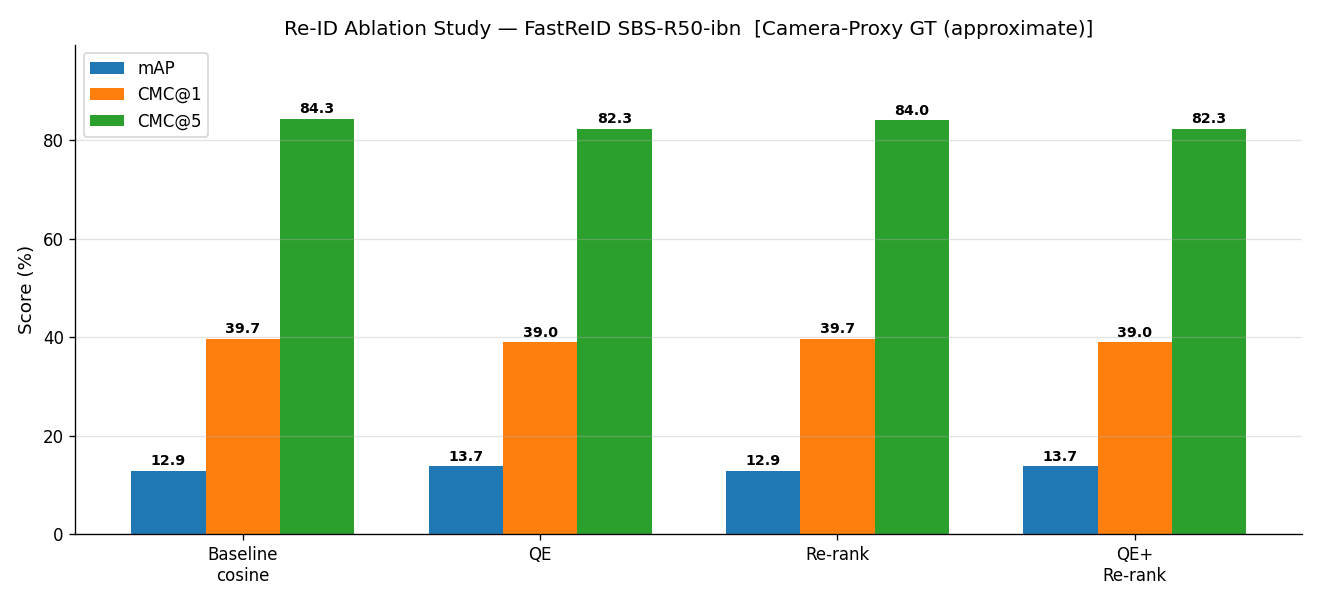

DIAGNOSTIC — Feature Similarity Distribution
Pairwise similarity (200 random tracklets):
  Mean  0.0154   (healthy: 0.30–0.50)
  Std   0.0795   (healthy: 0.15–0.25)
  Max   0.9351   (healthy: 0.70–0.90 for true matches)
⚠  Mean near zero — try pca_dim=256 or whiten=False.


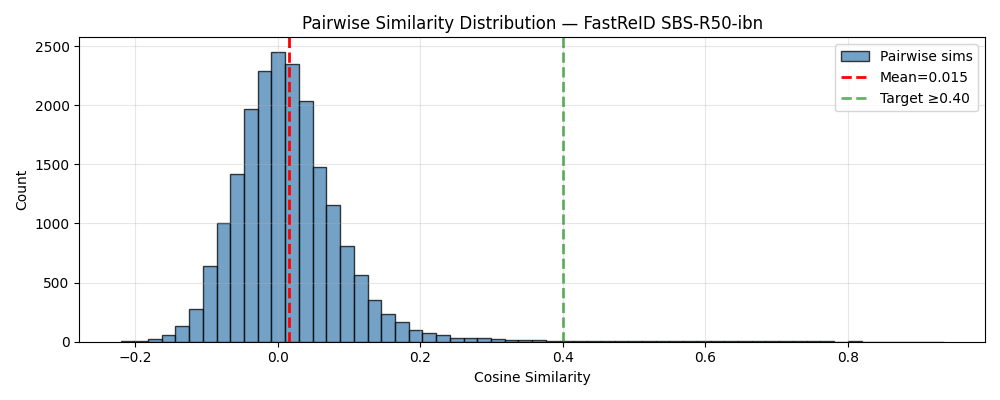

In [9]:
# CELL 9 — RE-ID EVALUATION: FULL ABLATION STUDY
# Runs 4 configurations and compares them in a table & bar chart

%matplotlib inline
import json, numpy as np, glob, time, sys
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage

N_PROXY_QUERIES  = 300
N_REAL_GT_QUERIES = 500

print("="*70)
print("RE-ID ABLATION STUDY — 4 CONFIGURATIONS")
print("="*70)

# ── Load features ──────────────────────────────────────────────────────────
data    = np.load(PATHS.features_path, allow_pickle=True)
features = data['features']
meta_raw = data['metadata']
if isinstance(meta_raw, np.ndarray) and meta_raw.ndim == 0: meta = meta_raw.item()
elif isinstance(meta_raw, np.ndarray):                       meta = list(meta_raw)
else:                                                        meta = meta_raw

# Sanitize NaN / Inf
n_bad = np.sum(~np.isfinite(features))
if n_bad > 0:
    print(f"Found {n_bad} non-finite values — sanitising...")
    features = np.nan_to_num(features, nan=0.0, posinf=1.0, neginf=-1.0)
    norms    = np.linalg.norm(features, axis=1, keepdims=True)
    features = features / (np.maximum(norms, 1e-8))

N, D = features.shape
print(f"Loaded embeddings  N={N}, D={D}  finite={'OK' if np.all(np.isfinite(features)) else 'BAD'}")

# ── Build tracklet lookup ──────────────────────────────────────────────────
tracklet_to_idx    = {m['tracklet_id']: i for i, m in enumerate(meta)}
tracklet_to_camera = {m['tracklet_id']: f"S{m.get('scenario','?')}c{m.get('camera_id','?')}"
                      for m in meta}

# ── Find AI City GT or fallback to proxy ──────────────────────────────────
HAS_REAL_GT = False
tracklet_to_vehicle = {}

candidates = [
    *glob.glob("/kaggle/input/**/train-tracks.json",  recursive=True),
    *glob.glob("/kaggle/input/**/train_tracks.json",  recursive=True),
    *glob.glob("/kaggle/input/**/gt/train-tracks.json", recursive=True),
    str(STAGE1_PATH / "train-tracks.json"),
]
gt_path = next((Path(p) for p in candidates if Path(p).exists()), None)

if gt_path is None:
    print("GT file not found. Scanning /kaggle/input for clues...")
    all_track_files = sorted(glob.glob("/kaggle/input/**/*track*", recursive=True))
    if all_track_files:
        print("Files containing 'track' in name:")
        for f in all_track_files[:30]: print(f"  {f}")
    else:
        print("No files with 'track' in name found under /kaggle/input")

if gt_path:
    print(f"Found AI City GT: {gt_path}")
    with open(gt_path) as f:
        raw_gt = json.load(f)
    print(f"GT entries (vehicles): {len(raw_gt)}")
    for vehicle_id, crops in raw_gt.items():
        for crop_path in crops:
            stem = Path(crop_path).stem
            for tid in tracklet_to_idx:
                if stem in tid or tid in stem:
                    tracklet_to_vehicle[tid] = vehicle_id
                    break
    print(f"Matched {len(tracklet_to_vehicle)} tracklets → vehicle IDs")
    HAS_REAL_GT = len(tracklet_to_vehicle) >= 10

# ── Build query / gallery / GT matrix ─────────────────────────────────────
gallery_indices = list(range(N))
gallery_feats   = features[gallery_indices]
query_indices   = []
gt_matrix       = {}

if HAS_REAL_GT:
    vehicle_to_tracklets = {}
    for tid, vid in tracklet_to_vehicle.items():
        vehicle_to_tracklets.setdefault(vid, []).append(tid)
    multi_track = {v: t for v, t in vehicle_to_tracklets.items() if len(t) >= 2}
    print(f"Vehicles with ≥2 tracklets: {len(multi_track)}")
    for vid, tids in list(multi_track.items())[:N_REAL_GT_QUERIES]:
        qt_id = tids[0]
        if qt_id not in tracklet_to_idx: continue
        q_idx    = tracklet_to_idx[qt_id]
        positives = [tracklet_to_idx[t] for t in tids[1:] if t in tracklet_to_idx]
        if positives:
            query_indices.append(q_idx)
            gt_matrix[q_idx] = positives
    print(f"Query tracklets: {len(query_indices)}")
    print(f"Gallery size:    {len(gallery_indices)}")
else:
    print("\nFalling back to camera-consistency proxy GT")
    print("(same scenario, different camera → assumed positive pair)")
    query_indices = list(range(min(N_PROXY_QUERIES, N)))
    for q_idx in query_indices:
        qm   = meta[q_idx]
        q_sc = qm.get('scenario',  'unknown')
        q_ca = qm.get('camera_id', -1)
        positives = [
            i for i, m in enumerate(meta)
            if m.get('scenario', 'unknown') == q_sc
            and m.get('camera_id', -1) != q_ca
            and i != q_idx
        ]
        if positives:
            gt_matrix[q_idx] = positives
    query_indices = [i for i in query_indices if i in gt_matrix]
    print(f"Proxy queries: {len(query_indices)}")
    print(f"Gallery size:  {len(gallery_indices)}")

raw_query_feats = features[query_indices]

# ── Pre-compute Query Expansion (configs 2 & 4) ───────────────────────────
print(f"\nPre-computing Query Expansion k={REID_CFG.qe_k}...")
t0 = time.time()
expanded_list = []
for q_idx in query_indices:
    q_feat      = features[q_idx]
    sims_init   = np.dot(gallery_feats, q_feat)
    sims_init[q_idx] = -1.0
    top_k_idx   = np.argsort(-sims_init)[:REID_CFG.qe_k]
    expanded    = np.mean(np.vstack([q_feat[np.newaxis]] +
                          [gallery_feats[i][np.newaxis] for i in top_k_idx]), axis=0)
    expanded_list.append(expanded / (np.linalg.norm(expanded) + 1e-8))
expanded_query_feats = np.vstack(expanded_list) if expanded_list else np.zeros((0, D))
print(f"QE done in {time.time()-t0:.1f}s  shape={expanded_query_feats.shape}")

# ── K-reciprocal Re-ranking ───────────────────────────────────────────────
try:
    FASTREID_ROOT = Path("/kaggle/working/fast-reid")
    if str(FASTREID_ROOT) not in sys.path:
        sys.path.insert(0, str(FASTREID_ROOT))
    from fastreid.evaluation.rerank import reranking
    print("FastReID rerank loaded.")
except (ImportError, ModuleNotFoundError):
    print("FastReID rerank not importable — using self-contained k-reciprocal re-ranking")

    def reranking(q_g_dist, q_q_dist, g_g_dist, k1=20, k2=6, lambda_value=0.3):
        """Zhong et al. CVPR 2017 k-reciprocal re-ranking."""
        q_g = q_g_dist.astype(np.float32)
        q_q = q_q_dist.astype(np.float32)
        g_g = g_g_dist.astype(np.float32)
        num_q, num_g = q_g.shape
        original_dist = np.concatenate(
            [np.concatenate([q_q, q_g], axis=1),
             np.concatenate([q_g.T, g_g], axis=1)], axis=0).astype(np.float32)
        original_dist = np.power(original_dist, 2)
        all_num       = original_dist.shape[0]
        original_dist = original_dist / (original_dist.max(axis=1, keepdims=True) + 1e-8)
        V             = np.zeros_like(original_dist, dtype=np.float32)
        initial_rank  = np.argsort(original_dist, axis=1)
        for i in range(all_num):
            forward  = set(initial_rank[i, 1:k1+1].tolist())
            backward = set()
            for j in forward:
                bwd = set(initial_rank[j, 1:int(np.round(k1/2))+1].tolist())
                if i in bwd:
                    backward.add(j)
            rr = forward & backward | {i}
            rr_ext = set(rr)
            for j in list(rr):
                fwd2 = set(initial_rank[j, 1:int(np.round(k1/2))+1].tolist())
                bwd2 = {jj for jj in fwd2
                        if j in set(initial_rank[jj, 1:int(np.round(k1/2))+1].tolist())}
                rr2 = fwd2 | bwd2
                if len(rr2) >= 2/3 * len(rr):
                    rr_ext |= rr2
            for j in rr_ext:
                V[i, j] = np.exp(-original_dist[i, j])
            V[i] = V[i] / (V[i].sum() + 1e-8)
        if k2 != 1:
            V_qe = np.zeros_like(V)
            for i in range(all_num):
                V_qe[i] = V[initial_rank[i, :k2]].mean(axis=0)
            V = V_qe
        inv_index    = [np.where(V[:, i] != 0)[0] for i in range(all_num)]
        jaccard_dist = np.zeros((num_q, num_g), dtype=np.float32)
        for i in range(num_q):
            temp_min  = np.zeros(num_g, dtype=np.float32)
            nonzero_q = np.where(V[i] != 0)[0]
            for j in nonzero_q:
                g_indices = inv_index[j][inv_index[j] >= num_q] - num_q
                temp_min[g_indices] = np.minimum(V[i, j], V[num_q + g_indices, j])
            jaccard_dist[i] = 1 - temp_min / (2 - temp_min + 1e-8)
        return (jaccard_dist * (1 - lambda_value) + q_g * lambda_value).astype(np.float32)

print(f"\nPre-computing Re-ranking matrices "
      f"k1={REID_CFG.rerank_k1}, k2={REID_CFG.rerank_k2}, λ={REID_CFG.rerank_lambda}...")

t0 = time.time()
qg = (1.0 - np.dot(raw_query_feats,     gallery_feats.T)).clip(0, 2)
qq = (1.0 - np.dot(raw_query_feats,     raw_query_feats.T)).clip(0, 2)
gg = (1.0 - np.dot(gallery_feats,       gallery_feats.T)).clip(0, 2)
reranked_raw = reranking(qg, qq, gg,
                         k1=REID_CFG.rerank_k1,
                         k2=REID_CFG.rerank_k2,
                         lambda_value=REID_CFG.rerank_lambda)
print(f"Re-ranking raw done in {time.time()-t0:.1f}s")

t0 = time.time()
qg_qe = (1.0 - np.dot(expanded_query_feats, gallery_feats.T)).clip(0, 2)
qq_qe = (1.0 - np.dot(expanded_query_feats, expanded_query_feats.T)).clip(0, 2)
reranked_qe = reranking(qg_qe, qq_qe, gg,
                        k1=REID_CFG.rerank_k1,
                        k2=REID_CFG.rerank_k2,
                        lambda_value=REID_CFG.rerank_lambda)
print(f"Re-ranking QE  done in {time.time()-t0:.1f}s")

# ── Evaluation helper ──────────────────────────────────────────────────────
def evaluate(q_feats, distmatrix, label):
    aps      = []
    cmc_hits = np.zeros(len(gallery_indices))

    for i, q_idx in enumerate(tqdm(query_indices, desc=f'  {label}', leave=False)):
        if q_idx not in gt_matrix or not gt_matrix[q_idx]:
            continue

        if distmatrix is not None:
            sims = -distmatrix[i].copy()       # distance → similarity
        else:
            sims = np.dot(gallery_feats, q_feats[i]).copy()

        sims[q_idx] = np.finfo(np.float32).min  # exclude self

        gt_flags = np.zeros(len(gallery_indices))
        for pos_idx in gt_matrix[q_idx]:
            if pos_idx < len(gallery_indices):
                gt_flags[pos_idx] = 1.0

        if gt_flags.sum() == 0:
            continue

        aps.append(average_precision_score(gt_flags, sims))
        ranking   = np.argsort(-sims)
        first_hit = np.where(gt_flags[ranking] == 1)[0]
        if len(first_hit) > 0:
            cmc_hits[first_hit[0]] += 1

    n   = len(aps) if aps else 1
    # ✅ FIXED: cumsum so CMC@k = fraction with first hit at rank ≤ k
    cmc = np.cumsum(cmc_hits) / n
    return {
        'mAP':   np.mean(aps) if aps else 0.0,
        'CMC1':  cmc[0],
        'CMC5':  cmc[4]  if len(cmc) >  4 else 0.0,
        'CMC10': cmc[9]  if len(cmc) >  9 else 0.0,
        'CMC20': cmc[19] if len(cmc) > 19 else 0.0,
        'n':     n,
    }

# ── Run all 4 configurations ───────────────────────────────────────────────
print("="*70)
print("Running 4 configurations...")
print("="*70)

configs = [
    ('1. Baseline cosine',  raw_query_feats,      None),
    ('2. Query Expansion',  expanded_query_feats,  None),
    ('3. Re-ranking only',  raw_query_feats,       reranked_raw),
    ('4. QE + Re-ranking',  expanded_query_feats,  reranked_qe),
]

results = {}
for label, qfeats, distmat in configs:
    t0 = time.time()
    r  = evaluate(qfeats, distmat, label)
    results[label] = r
    print(f"  {label:30s}  mAP={r['mAP']:.2f}  CMC1={r['CMC1']*100:.1f}%  {time.time()-t0:.1f}s")

# ── Print comparison table ─────────────────────────────────────────────────
gt_label    = "AI City GT" if HAS_REAL_GT else "Camera-Proxy GT (approximate)"
baseline_map = results['1. Baseline cosine']['mAP']

print("="*70)
print(f"ABLATION STUDY RESULTS  [{gt_label}]")
print("="*70)
print(f"  {'Configuration':30}  {'mAP':>7}  {'CMC@1':>7}  {'CMC@5':>7}  {'CMC@10':>8}  {'CMC@20':>8}")
print(f"  {'-'*30}  {'-'*7}  {'-'*7}  {'-'*7}  {'-'*8}  {'-'*8}")
for label, r in results.items():
    delta = r['mAP'] - baseline_map
    arrow = (f" ▲{delta:.2f}" if delta > 0.001 else
             f" ▼{abs(delta):.2f}" if delta < -0.001 else "")
    print(f"  {label:30}  {r['mAP']:>7.2f}  {r['CMC1']*100:>7.2f}  "
          f"{r['CMC5']*100:>7.2f}  {r['CMC10']*100:>8.2f}  {r['CMC20']*100:>8.2f}{arrow}")
print("="*70)
print(f"Queries evaluated: {results['1. Baseline cosine']['n']}  (* = improvement over baseline)")

# ── Bar chart ──────────────────────────────────────────────────────────────
labels    = ['Baseline\ncosine', 'QE', 'Re-rank', 'QE+\nRe-rank']
map_vals  = [results[k]['mAP']   * 100 for k in results]
cmc1_vals = [results[k]['CMC1']  * 100 for k in results]
cmc5_vals = [results[k]['CMC5']  * 100 for k in results]

x, width = np.arange(len(labels)), 0.25
fig, ax  = plt.subplots(figsize=(11, 5))
for bars, vals, lbl, col in [
    (ax.bar(x - width, map_vals,  width), map_vals,  'mAP',   'steelblue'),
    (ax.bar(x,         cmc1_vals, width), cmc1_vals, 'CMC@1', 'darkorange'),
    (ax.bar(x + width, cmc5_vals, width), cmc5_vals, 'CMC@5', 'seagreen'),
]:
    bars[0].set_label(lbl)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.1f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x);  ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title(f'Re-ID Ablation Study — FastReID SBS-R50-ibn  [{gt_label}]', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, min(110, max(map_vals + cmc1_vals + cmc5_vals) + 15))
ax.grid(axis='y', alpha=0.35)
ax.spines['top'].set_visible(False);  ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/kaggle/working/ablation_study.png', dpi=120)
plt.close()
display(IPImage('/kaggle/working/ablation_study.png'))

# ── Similarity distribution diagnostic ────────────────────────────────────
print("="*70)
print("DIAGNOSTIC — Feature Similarity Distribution")
print("="*70)
sample   = features[:200]
sim_s    = np.dot(sample, sample.T)
np.fill_diagonal(sim_s, 0)
off_diag = sim_s[np.triu_indices(200, k=1)]

print(f"Pairwise similarity (200 random tracklets):")
print(f"  Mean  {off_diag.mean():.4f}   (healthy: 0.30–0.50)")
print(f"  Std   {off_diag.std():.4f}   (healthy: 0.15–0.25)")
print(f"  Max   {off_diag.max():.4f}   (healthy: 0.70–0.90 for true matches)")

if   off_diag.mean() < 0.05:  print("⚠  Mean near zero — try pca_dim=256 or whiten=False.")
elif off_diag.mean() < 0.20:  print("⚠  Mean low — features partially collapsed.")
else:                          print("✅ Similarity distribution looks healthy.")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(off_diag, bins=60, edgecolor='black', alpha=0.75, color='steelblue', label='Pairwise sims')
ax.axvline(off_diag.mean(), color='red',   linestyle='--', lw=2, label=f'Mean={off_diag.mean():.3f}')
ax.axvline(0.40,             color='green', linestyle='--', lw=2, alpha=0.6, label='Target ≥0.40')
ax.set_xlabel('Cosine Similarity');  ax.set_ylabel('Count')
ax.set_title('Pairwise Similarity Distribution — FastReID SBS-R50-ibn')
ax.legend();  ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/similarity_distribution.png', dpi=100)
plt.close()
display(IPImage('/kaggle/working/similarity_distribution.png'))
print("="*70)



🖼️  VISUAL RESULTS: Top-10 Matches for Random Queries

📸 Visualizing 3 random queries...
   (Border: Green = confirmed GT match | Orange = high sim | Gray = low sim)


🔍 Query: track_04657  |  Camera: 34


/tmp/ipykernel_24/838605759.py:101: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24/838605759.py:103: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=100, bbox_inches='tight')


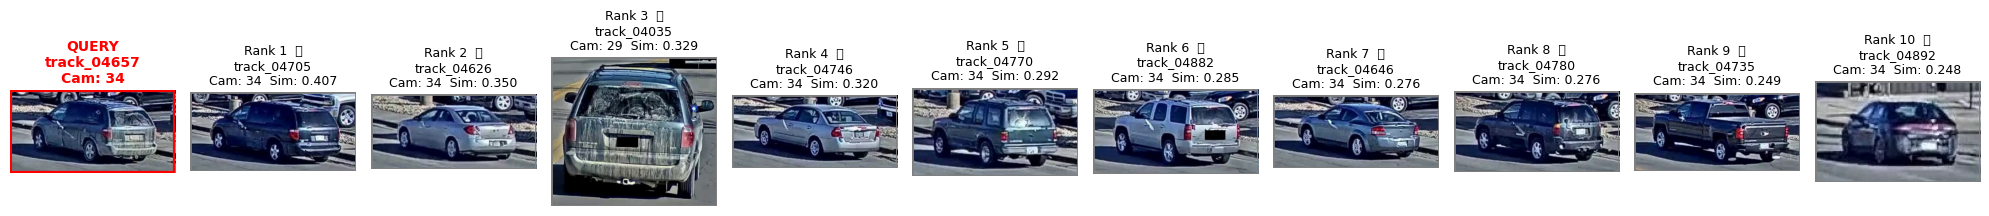


📊 Top-10 Matches:
Rank   Tracklet ID          Camera     Similarity   GT Match?
----------------------------------------------------------------------
1      track_04705          34         0.4069       ❌ FALSE
2      track_04626          34         0.3496       ❌ FALSE
3      track_04035          29         0.3285       ❌ FALSE
4      track_04746          34         0.3200       ❌ FALSE
5      track_04770          34         0.2920       ❌ FALSE
6      track_04882          34         0.2852       ❌ FALSE
7      track_04646          34         0.2761       ❌ FALSE
8      track_04780          34         0.2755       ❌ FALSE
9      track_04735          34         0.2488       ❌ FALSE
10     track_04892          34         0.2484       ❌ FALSE


🔍 Query: track_02957  |  Camera: 21


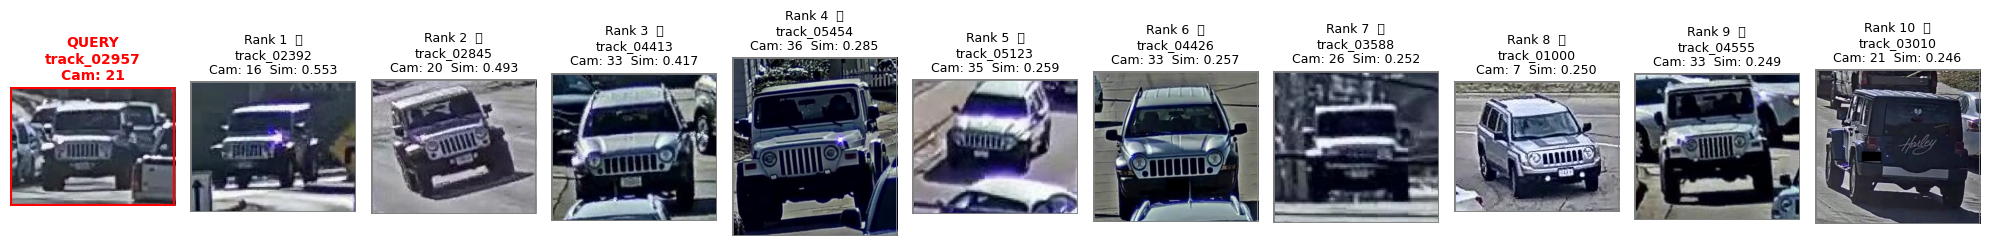


📊 Top-10 Matches:
Rank   Tracklet ID          Camera     Similarity   GT Match?
----------------------------------------------------------------------
1      track_02392          16         0.5530       ❌ FALSE
2      track_02845          20         0.4932       ❌ FALSE
3      track_04413          33         0.4171       ❌ FALSE
4      track_05454          36         0.2846       ❌ FALSE
5      track_05123          35         0.2590       ❌ FALSE
6      track_04426          33         0.2569       ❌ FALSE
7      track_03588          26         0.2523       ❌ FALSE
8      track_01000          7          0.2500       ❌ FALSE
9      track_04555          33         0.2487       ❌ FALSE
10     track_03010          21         0.2459       ❌ FALSE


🔍 Query: track_04280  |  Camera: 33


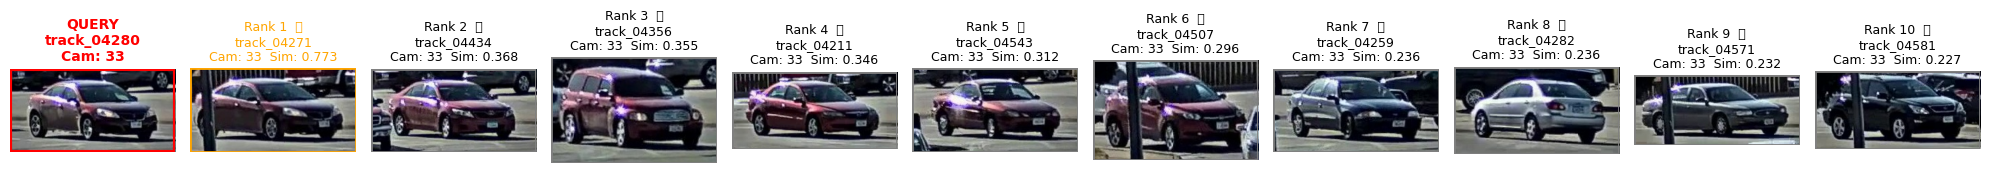


📊 Top-10 Matches:
Rank   Tracklet ID          Camera     Similarity   GT Match?
----------------------------------------------------------------------
1      track_04271          33         0.7727       ❌ FALSE
2      track_04434          33         0.3684       ❌ FALSE
3      track_04356          33         0.3553       ❌ FALSE
4      track_04211          33         0.3461       ❌ FALSE
5      track_04543          33         0.3119       ❌ FALSE
6      track_04507          33         0.2964       ❌ FALSE
7      track_04259          33         0.2358       ❌ FALSE
8      track_04282          33         0.2356       ❌ FALSE
9      track_04571          33         0.2322       ❌ FALSE
10     track_04581          33         0.2271       ❌ FALSE

✅ Visualization complete!
💾 Images saved to /kaggle/working/query_*_top10.png


In [10]:
# ============================================================================
# CELL 10: VISUALIZATION — Top-10 Matches for Random Queries
# ============================================================================

%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from IPython.display import display, Image as IPImage
import numpy as np
from pathlib import Path

print("\n" + "="*70)
print("🖼️  VISUAL RESULTS: Top-10 Matches for Random Queries")
print("="*70)

def visualize_top_matches(query_idx, features, meta, gt_matrix, top_k=10):
    """
    Visualize a query and its top-K most similar matches.
    Uses real gt_matrix from Cell 9 for correct TRUE/FALSE labels.
    """
    query_feat   = features[query_idx]
    similarities = np.dot(features, query_feat)  # cosine (L2-normed features)

    # Top-K excluding self
    sorted_indices = np.argsort(-similarities)
    top_matches    = [idx for idx in sorted_indices if idx != query_idx][:top_k]

    # Query metadata
    query_meta     = meta[query_idx]
    query_tracklet = query_meta['tracklet_id']
    query_camera   = query_meta.get('camera_id', 'unknown')
    query_crops    = query_meta.get('crop_paths', [])

    print(f"\n{'='*70}")
    print(f"🔍 Query: {query_tracklet}  |  Camera: {query_camera}")
    print(f"{'='*70}")

    # ── Figure ──────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(20, 4))

    # Query image (leftmost column)
    ax = plt.subplot(1, top_k + 1, 1)
    if query_crops:
        qpath = Path(query_crops[len(query_crops) // 2])
        if qpath.exists():
            ax.imshow(Image.open(qpath))
        else:
            ax.text(0.5, 0.5, 'Image\nNot Found', ha='center', va='center',
                    transform=ax.transAxes)
    ax.set_title(f"QUERY\n{query_tracklet}\nCam: {query_camera}",
                 fontsize=10, fontweight='bold', color='red')
    ax.axis('off')
    ax.add_patch(patches.Rectangle(
        (0, 0), 1, 1, linewidth=3, edgecolor='red',
        facecolor='none', transform=ax.transAxes))

    # Match images
    real_positives = set(gt_matrix.get(query_idx, []))

    for i, match_idx in enumerate(top_matches):
        ax = plt.subplot(1, top_k + 1, i + 2)

        match_meta     = meta[match_idx]
        match_tracklet = match_meta['tracklet_id']
        match_camera   = match_meta.get('camera_id', 'unknown')
        match_crops    = match_meta.get('crop_paths', [])
        similarity     = similarities[match_idx]
        is_real_match  = match_idx in real_positives

        # Image
        if match_crops:
            mpath = Path(match_crops[len(match_crops) // 2])
            if mpath.exists():
                ax.imshow(Image.open(mpath))
            else:
                ax.text(0.5, 0.5, 'Image\nNot Found', ha='center', va='center',
                        transform=ax.transAxes)

        # Color: green = confirmed match, orange = high sim but unconfirmed, gray = low
        if is_real_match:
            title_color  = 'green'
            border_color = 'green'
        elif similarity > 0.6:
            title_color  = 'orange'
            border_color = 'orange'
        else:
            title_color  = 'black'
            border_color = 'gray'

        match_label = "✅" if is_real_match else "❌"
        ax.set_title(f"Rank {i+1}  {match_label}\n{match_tracklet}\n"
                     f"Cam: {match_camera}  Sim: {similarity:.3f}",
                     fontsize=9, color=title_color)
        ax.axis('off')
        ax.add_patch(patches.Rectangle(
            (0, 0), 1, 1, linewidth=2, edgecolor=border_color,
            facecolor='none', transform=ax.transAxes))

    plt.tight_layout()
    save_path = f'/kaggle/working/query_{query_idx}_top10.png'
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.close()                   # free memory — must come before display()
    display(IPImage(save_path))   # render saved file into notebook output

    # ── Printed table ────────────────────────────────────────────────────────
    print(f"\n📊 Top-{top_k} Matches:")
    print(f"{'Rank':<6} {'Tracklet ID':<20} {'Camera':<10} {'Similarity':<12} {'GT Match?'}")
    print("-" * 70)
    for i, match_idx in enumerate(top_matches):
        m          = meta[match_idx]
        sim        = similarities[match_idx]
        is_match   = "✅ TRUE" if match_idx in real_positives else "❌ FALSE"
        print(f"{i+1:<6} {m['tracklet_id']:<20} {str(m.get('camera_id','?')):<10} "
              f"{sim:<12.4f} {is_match}")


# ── Run on 3 random queries ──────────────────────────────────────────────────
np.random.seed(42)
num_to_show          = min(3, len(features))
random_query_indices = np.random.choice(len(features), num_to_show, replace=False)

print(f"\n📸 Visualizing {num_to_show} random queries...")
print("   (Border: Green = confirmed GT match | Orange = high sim | Gray = low sim)\n")

for query_idx in random_query_indices:
    visualize_top_matches(
        query_idx  = int(query_idx),
        features   = features,
        meta       = meta,
        gt_matrix  = gt_matrix,   # ← real GT from Cell 9
        top_k      = 10
    )
    print()

print("="*70)
print("✅ Visualization complete!")
print(f"💾 Images saved to /kaggle/working/query_*_top10.png")
print("="*70)
